In [1]:
import pandas as pd
import numpy as np
import ast
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import AgglomerativeClustering
import pickle

C:\Users\Jay Patel\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv(r'C:\Users\Jay Patel\Campusx\ml_projects\PropNavigator\notebooks\recommender\real_estate.csv')
df

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Pa...","{'Bajghera Road': '800 Meter', 'Palam Vihar Ha...",https://www.99acres.com/smartworld-one-dxp-sec...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Swimming Pool', 'Salon', 'Restaurant', 'Spa'..."
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap Un...","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The N...",https://www.99acres.com/m3m-crown-sector-111-g...,"{'3 BHK': {'building_type': 'Apartment', 'area...","['Bowling Alley', 'Mini Theatre', 'Manicured G..."
2,Adani Brahma Samsara Vilasa,"Land, 3, 4 BHK Independent Floor in Sector 63,...","['AIPL Business Club Sector 62', 'Heritage Xpe...","{'AIPL Business Club Sector 62': '2.7 Km', 'He...",https://www.99acres.com/adani-brahma-samsara-v...,{'3 BHK': {'building_type': 'Independent Floor...,"['Terrace Garden', 'Gazebo', 'Fountain', 'Amph..."
3,Sobha City,"2, 3, 4 BHK Apartment in Sector 108, Gurgaon","['The Shikshiyan School', 'WTC Plaza', 'Luxus ...","{'The Shikshiyan School': '2.9 KM', 'WTC Plaza...",https://www.99acres.com/sobha-city-sector-108-...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Swimming Pool', 'Volley Ball Court', 'Aerobi..."
4,Signature Global City 93,"2, 3 BHK Independent Floor in Sector 93 Gurgaon","['Pranavananda Int. School', 'DLF Site central...","{'Pranavananda Int. School': '450 m', 'DLF Sit...",https://www.99acres.com/signature-global-city-...,{'2 BHK': {'building_type': 'Independent Floor...,"['Mini Theatre', 'Doctor on Call', 'Concierge ..."
...,...,...,...,...,...,...,...
242,DLF Princeton Estate,"2, 3, 4 BHK Apartment in DLF Phase 5, Gurgaon","['Sector 42-43 Metro Station', 'Paras Hospital...","{'Sector 42-43 Metro Station': '1.8 Km', 'Para...",https://www.99acres.com/dlf-princeton-estate-d...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Swimming Pool', 'Medical Centre', 'Laundry',..."
243,Pyramid Urban Homes 2,"1, 2 BHK Apartment in Sector 86, Gurgaon","['Aarvy Healthcare Super Speciality', ""St. Xav...",{'Aarvy Healthcare Super Speciality': '1.8 KM'...,https://www.99acres.com/pyramid-urban-homes-2-...,"{'1 BHK': {'building_type': 'Apartment', 'area...","['Shopping Centre', 'Community Hall', '24x7 Se..."
244,Satya The Hermitage,"2, 3, 4, 5 BHK Apartment in Sector 103, Gurgaon","['Dwarka Expressway', 'S N International Schoo...","{'Dwarka Expressway': '1.2 Km', 'S N Internati...",https://www.99acres.com/satya-the-hermitage-se...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Bus Shelter', 'Swimming Pool', 'Business Lou..."
245,BPTP Spacio,"2, 3 BHK Apartment in Sector 37D, Gurgaon","['Suncity School', 'Gurugram Road', 'Dwarka Ex...","{'Suncity School': '0.2 Km', 'Gurugram Road': ...",https://www.99acres.com/bptp-spacio-sector-37d...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Swimming Pool', 'Card Room', 'Piped Gas', 'P..."


In [3]:
df = df.drop(22)

In [4]:
df.iloc[0]['PropertySubName']

'2, 3, 4 BHK Apartment in Sector 113, Gurgaon'

In [5]:
df.iloc[0]['NearbyLocations']

"['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']"

In [6]:
df.iloc[0]['LocationAdvantages']

"{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}"

In [7]:
df[['PropertyName','TopFacilities']]

,PropertyName,TopFacilities
0,Smartworld One DXP,"['Swimming Pool', 'Salon', 'Restaurant', 'Spa'..."
1,M3M Crown,"['Bowling Alley', 'Mini Theatre', 'Manicured G..."
2,Adani Brahma Samsara Vilasa,"['Terrace Garden', 'Gazebo', 'Fountain', 'Amph..."
3,Sobha City,"['Swimming Pool', 'Volley Ball Court', 'Aerobi..."
4,Signature Global City 93,"['Mini Theatre', 'Doctor on Call', 'Concierge ..."
...,...,...
242,DLF Princeton Estate,"['Swimming Pool', 'Medical Centre', 'Laundry',..."
243,Pyramid Urban Homes 2,"['Shopping Centre', 'Community Hall', '24x7 Se..."
244,Satya The Hermitage,"['Bus Shelter', 'Swimming Pool', 'Business Lou..."
245,BPTP Spacio,"['Swimming Pool', 'Card Room', 'Piped Gas', 'P..."


In [8]:
df.iloc[100]['TopFacilities']

"['School', 'High Speed Elevators', 'Creche/Day care', 'Shopping Centre', 'Cricket Pitch', 'Amphitheatre', 'Earthquake Resistant', 'Power Back up Lift', 'Party Lawn']"

In [9]:
def parse_top_facilities(x):
    if isinstance(x, list):
        return x                  
    if not isinstance(x, str) or x.strip() == "":
        return []
    try:
        return ast.literal_eval(x)
    except:
        return []


In [10]:
df['TopFacilities_list'] =  df['TopFacilities'].apply(parse_top_facilities)
df['TopFacilities_list']

0      [Swimming Pool, Salon, Restaurant, Spa, Cafete...
1      [Bowling Alley, Mini Theatre, Manicured Garden...
2      [Terrace Garden, Gazebo, Fountain, Amphitheatr...
3      [Swimming Pool, Volley Ball Court, Aerobics Ce...
4      [Mini Theatre, Doctor on Call, Concierge Servi...
                             ...                        
242    [Swimming Pool, Medical Centre, Laundry, Salon...
243    [Shopping Centre, Community Hall, 24x7 Securit...
244    [Bus Shelter, Swimming Pool, Business Lounge, ...
245    [Swimming Pool, Card Room, Piped Gas, Pool Tab...
246    [Swimming Pool, School, Solar Lighting, Aerobi...
Name: TopFacilities_list, Length: 246, dtype: object

In [11]:
df['FacilitiesStr'] = df['TopFacilities_list'].apply(' '.join)

In [12]:
df['FacilitiesStr']

0      Swimming Pool Salon Restaurant Spa Cafeteria S...
1      Bowling Alley Mini Theatre Manicured Garden Sw...
2      Terrace Garden Gazebo Fountain Amphitheatre Pa...
3      Swimming Pool Volley Ball Court Aerobics Centr...
4      Mini Theatre Doctor on Call Concierge Service ...
                             ...                        
242    Swimming Pool Medical Centre Laundry Salon Gro...
243    Shopping Centre Community Hall 24x7 Security G...
244    Bus Shelter Swimming Pool Business Lounge Read...
245    Swimming Pool Card Room Piped Gas Pool Table S...
246    Swimming Pool School Solar Lighting Aerobics C...
Name: FacilitiesStr, Length: 246, dtype: object

In [13]:
df['FacilitiesStr'][0]

'Swimming Pool Salon Restaurant Spa Cafeteria Sun Deck 24x7 Security Club House Gated Community'

In [14]:
tfidf_vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))

In [15]:
tfidf_matrix = tfidf_vectorizer.fit_transform(df['FacilitiesStr'])

In [16]:
tfidf_matrix.toarray()[0]

array([0.        , 0.        , 0.        , 0.18809342, 0.18809342,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [17]:
tfidf_matrix.shape

(246, 973)

- We have 246 vectors in a 973 dimensional space

In [18]:
cosine_sim_top_features = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [19]:
cosine_sim_top_features.shape

(246, 246)

- How similar property i is to property j based on facilities

In [20]:
df[['PropertyName','PriceDetails']]['PriceDetails'][1]

"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}"

In [21]:
df.index[df['PropertyName'] == 'DLF The Arbour'][0]

11

In [22]:
scores = pd.Series(cosine_sim_top_features[11], index=df.index)
scores

0      0.353724
1      0.029323
2      0.117620
3      0.009155
4      0.020446
         ...   
242    0.009419
243    0.325000
244    0.009992
245    0.015089
246    0.009350
Length: 246, dtype: float64

In [23]:
scores

0      0.353724
1      0.029323
2      0.117620
3      0.009155
4      0.020446
         ...   
242    0.009419
243    0.325000
244    0.009992
245    0.015089
246    0.009350
Length: 246, dtype: float64

In [24]:
def recommend_properties(property_name, cosine_sim, top_n=5):

    idx = df.index[df['PropertyName'] == property_name][0]

    scores = pd.Series(cosine_sim[idx], index=df.index)

    top_scores = (
        scores
        .drop(idx)            # remove self similarity
        .sort_values(ascending=False)
        .head(top_n)
    )

    return pd.DataFrame({
        'PropertyName': df.loc[top_scores.index, 'PropertyName'],
        'SimilarityScore': top_scores.values
    })


In [25]:
recommend_properties("DLF The Arbour", cosine_sim_top_features)

,PropertyName,SimilarityScore
64,Ace Palm Floors,0.551341
93,JMS The Nation,0.483993
217,Yashika 104,0.479193
18,Whiteland Blissville,0.469080
63,Vatika Aspiration,0.416082


#### Recommendation based on Price, Area and Property Type

In [26]:
def summarize_price_details(detail_str):
    
    if not isinstance(detail_str, str) or detail_str.strip() == "":
        return {}

    try:
        details = ast.literal_eval(detail_str)
    except:
        return {}

    prices = []
    areas = []
    bhks = []
    building_types = []

    for bhk, info in details.items():

        # ---- BHK ----
        bhk_num = re.findall(r'\d+', bhk)
        if bhk_num:
            bhks.append(int(bhk_num[0]))

        # ---- Building type ----
        if isinstance(info, dict):
            building_types.append(info.get('building_type'))

        # ---- Area ----
        area = info.get('area', '')
        area_nums = re.findall(r'[\d,]+', area)
        areas.extend([float(n.replace(',', '')) for n in area_nums])

        # ---- Price ----
        price = info.get('price-range', '')
        price_nums = re.findall(r'[\d.]+', price)

        if price_nums:
            values = [float(n) for n in price_nums]
            if 'L' in price:
                values = [v / 100 for v in values]  # Lakhs → Cr
            prices.extend(values)

    return {
        'min_price_cr': min(prices) if prices else np.nan,
        'max_price_cr': max(prices) if prices else np.nan,
        'avg_price_cr': np.mean(prices) if prices else np.nan,
        'min_area_sqft': min(areas) if areas else np.nan,
        'max_area_sqft': max(areas) if areas else np.nan,
        'avg_area_sqft': np.mean(areas) if areas else np.nan,
        'min_bhk': min(bhks) if bhks else np.nan,
        'max_bhk': max(bhks) if bhks else np.nan,
        'property_type': building_types[0] if building_types else np.nan
    }


In [27]:
price_features = df['PriceDetails'].apply(summarize_price_details)
price_df = pd.DataFrame(price_features.tolist(), index=df['PropertyName'])

In [28]:
price_features

0      {'min_price_cr': 2.0, 'max_price_cr': 4.56, 'a...
1      {'min_price_cr': 2.2, 'max_price_cr': 3.73, 'a...
2      {'min_price_cr': 2.05, 'max_price_cr': 41.13, ...
3      {'min_price_cr': 1.55, 'max_price_cr': 6.06, '...
4      {'min_price_cr': 0.0106, 'max_price_cr': 1.45,...
                             ...                        
242    {'min_price_cr': 1.35, 'max_price_cr': 2.15, '...
243    {'min_price_cr': 0.2345, 'max_price_cr': 0.278...
244    {'min_price_cr': 0.8, 'max_price_cr': 2.14, 'a...
245    {'min_price_cr': nan, 'max_price_cr': nan, 'av...
246    {'min_price_cr': 1.1, 'max_price_cr': 1.19, 'a...
Name: PriceDetails, Length: 246, dtype: object

In [29]:
df['PriceDetails'][0]

"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}"

In [30]:
price_df

,min_price_cr,max_price_cr,avg_price_cr,min_area_sqft,max_area_sqft,avg_area_sqft,min_bhk,max_bhk,property_type
PropertyName,,,,,,,,,
Smartworld One DXP,2.0000,4.5600,3.006667,1370.0,2600.0,1967.500000,2.0,4.0,Apartment
M3M Crown,2.2000,3.7300,3.010000,1605.0,2670.0,2173.250000,3.0,4.0,Apartment
Adani Brahma Samsara Vilasa,2.0500,41.1300,14.536667,500.0,4500.0,2838.166667,3.0,4.0,Independent Floor
Sobha City,1.5500,6.0600,3.311667,1381.0,2963.0,2085.500000,2.0,4.0,Apartment
Signature Global City 93,0.0106,1.4500,0.877675,981.0,1530.0,1216.000000,2.0,3.0,Independent Floor
...,...,...,...,...,...,...,...,...,...
DLF Princeton Estate,1.3500,2.1500,1.683333,964.0,1562.0,1217.666667,2.0,4.0,Apartment
Pyramid Urban Homes 2,0.2345,0.2786,0.256550,335.0,625.0,464.500000,1.0,2.0,Apartment
Satya The Hermitage,0.8000,2.1400,1.285000,1450.0,4731.0,3104.400000,2.0,5.0,Apartment


In [34]:
pickle.dump(price_df, open(r'C:\Users\Jay Patel\Campusx\ml_projects\PropNavigator\data\recommender\price_df.pkl','wb'))

In [35]:
# Identify numerical columns for Log Transformation
# We exclude the 'property_type' because it's categorical
num_cols = ['min_price_cr', 'max_price_cr', 'avg_price_cr', 
            'min_area_sqft', 'max_area_sqft', 'avg_area_sqft', 
            'min_bhk', 'max_bhk']

In [36]:
# This handles the "long tail" of expensive/large properties
price_df[num_cols] = np.log1p(price_df[num_cols])

In [37]:
price_df = pd.get_dummies(price_df, columns=['property_type'], drop_first=True)
price_df.fillna(price_df.mean(), inplace=True)

price_scaled = StandardScaler().fit_transform(price_df)

In [38]:
price_scaled

array([[ 2.66010419e-01,  2.27605880e-01,  1.68899063e-01, ...,
        -6.38876565e-02, -6.38876565e-02, -1.94870941e-01],
       [ 3.79445021e-01,  1.24310782e-02,  1.70215400e-01, ...,
        -6.38876565e-02, -6.38876565e-02, -1.94870941e-01],
       [ 2.95062755e-01,  2.92294821e+00,  2.31410552e+00, ...,
        -6.38876565e-02, -6.38876565e-02, -1.94870941e-01],
       ...,
       [-6.31830137e-01, -5.32852827e-01, -7.20044165e-01, ...,
        -6.38876565e-02, -6.38876565e-02, -1.94870941e-01],
       [ 0.00000000e+00,  2.95525114e-16, -3.51473098e-16, ...,
        -6.38876565e-02, -6.38876565e-02, -1.94870941e-01],
       [-3.60890846e-01, -1.01241404e+00, -8.20124975e-01, ...,
        -6.38876565e-02, -6.38876565e-02, -1.94870941e-01]])

In [39]:
cosine_sim_price = cosine_similarity(price_scaled)

In [40]:
cosine_sim_price.shape

(246, 246)

In [41]:
recommend_properties("DLF The Arbour", cosine_sim_price, top_n= 20)

,PropertyName,SimilarityScore
137,DLF The Pinnacle,0.999790
230,DLF The Summit,0.994653
151,Paras Quartier,0.983230
142,DLF The Icon,0.973261
107,DLF The Belaire,0.927527
58,DLF The Aralias,0.918488
19,Trump Tower,0.916600
57,DLF The Magnolias,0.906114
214,Salcon The Verandas,0.905630
201,Vipul Belmonte,0.895219


In [42]:
df

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities,TopFacilities_list,FacilitiesStr
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Pa...","{'Bajghera Road': '800 Meter', 'Palam Vihar Ha...",https://www.99acres.com/smartworld-one-dxp-sec...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Swimming Pool', 'Salon', 'Restaurant', 'Spa'...","[Swimming Pool, Salon, Restaurant, Spa, Cafete...",Swimming Pool Salon Restaurant Spa Cafeteria S...
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap Un...","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The N...",https://www.99acres.com/m3m-crown-sector-111-g...,"{'3 BHK': {'building_type': 'Apartment', 'area...","['Bowling Alley', 'Mini Theatre', 'Manicured G...","[Bowling Alley, Mini Theatre, Manicured Garden...",Bowling Alley Mini Theatre Manicured Garden Sw...
2,Adani Brahma Samsara Vilasa,"Land, 3, 4 BHK Independent Floor in Sector 63,...","['AIPL Business Club Sector 62', 'Heritage Xpe...","{'AIPL Business Club Sector 62': '2.7 Km', 'He...",https://www.99acres.com/adani-brahma-samsara-v...,{'3 BHK': {'building_type': 'Independent Floor...,"['Terrace Garden', 'Gazebo', 'Fountain', 'Amph...","[Terrace Garden, Gazebo, Fountain, Amphitheatr...",Terrace Garden Gazebo Fountain Amphitheatre Pa...
3,Sobha City,"2, 3, 4 BHK Apartment in Sector 108, Gurgaon","['The Shikshiyan School', 'WTC Plaza', 'Luxus ...","{'The Shikshiyan School': '2.9 KM', 'WTC Plaza...",https://www.99acres.com/sobha-city-sector-108-...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Swimming Pool', 'Volley Ball Court', 'Aerobi...","[Swimming Pool, Volley Ball Court, Aerobics Ce...",Swimming Pool Volley Ball Court Aerobics Centr...
4,Signature Global City 93,"2, 3 BHK Independent Floor in Sector 93 Gurgaon","['Pranavananda Int. School', 'DLF Site central...","{'Pranavananda Int. School': '450 m', 'DLF Sit...",https://www.99acres.com/signature-global-city-...,{'2 BHK': {'building_type': 'Independent Floor...,"['Mini Theatre', 'Doctor on Call', 'Concierge ...","[Mini Theatre, Doctor on Call, Concierge Servi...",Mini Theatre Doctor on Call Concierge Service ...
...,...,...,...,...,...,...,...,...,...
242,DLF Princeton Estate,"2, 3, 4 BHK Apartment in DLF Phase 5, Gurgaon","['Sector 42-43 Metro Station', 'Paras Hospital...","{'Sector 42-43 Metro Station': '1.8 Km', 'Para...",https://www.99acres.com/dlf-princeton-estate-d...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Swimming Pool', 'Medical Centre', 'Laundry',...","[Swimming Pool, Medical Centre, Laundry, Salon...",Swimming Pool Medical Centre Laundry Salon Gro...
243,Pyramid Urban Homes 2,"1, 2 BHK Apartment in Sector 86, Gurgaon","['Aarvy Healthcare Super Speciality', ""St. Xav...",{'Aarvy Healthcare Super Speciality': '1.8 KM'...,https://www.99acres.com/pyramid-urban-homes-2-...,"{'1 BHK': {'building_type': 'Apartment', 'area...","['Shopping Centre', 'Community Hall', '24x7 Se...","[Shopping Centre, Community Hall, 24x7 Securit...",Shopping Centre Community Hall 24x7 Security G...
244,Satya The Hermitage,"2, 3, 4, 5 BHK Apartment in Sector 103, Gurgaon","['Dwarka Expressway', 'S N International Schoo...","{'Dwarka Expressway': '1.2 Km', 'S N Internati...",https://www.99acres.com/satya-the-hermitage-se...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Bus Shelter', 'Swimming Pool', 'Business Lou...","[Bus Shelter, Swimming Pool, Business Lounge, ...",Bus Shelter Swimming Pool Business Lounge Read...
245,BPTP Spacio,"2, 3 BHK Apartment in Sector 37D, Gurgaon","['Suncity School', 'Gurugram Road', 'Dwarka Ex...","{'Suncity School': '0.2 Km', 'Gurugram Road': ...",https://www.99acres.com/bptp-spacio-sector-37d...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Swimming Pool', 'Card Room', 'Piped Gas', 'P...","[Swimming Pool, Card Room, Piped Gas, Pool Tab...",Swimming Pool Card Room Pi

In [43]:
names = ["DLF The Arbour", "DLF The Pinnacle", "DLF The Summit","Paras Quartier"]
df[df['PropertyName'].isin(names)]['PriceDetails']

11     {'4 BHK': {'building_type': 'Apartment', 'area...
137    {'4 BHK': {'building_type': 'Apartment', 'area...
151    {'4 BHK': {'building_type': 'Apartment', 'area...
230    {'4 BHK': {'building_type': 'Apartment', 'area...
Name: PriceDetails, dtype: object

In [44]:
recommend_properties("DLF The Arbour", cosine_sim_price, top_n= 20)

,PropertyName,SimilarityScore
137,DLF The Pinnacle,0.999790
230,DLF The Summit,0.994653
151,Paras Quartier,0.983230
142,DLF The Icon,0.973261
107,DLF The Belaire,0.927527
58,DLF The Aralias,0.918488
19,Trump Tower,0.916600
57,DLF The Magnolias,0.906114
214,Salcon The Verandas,0.905630
201,Vipul Belmonte,0.895219


1. Problem Statement : I wanted to build a content-based recommendation system for real-estate properties based on pricing information.

Each property had complex nested price details, like:

Multiple configurations (2 BHK, 3 BHK, 4 BHK)

Each with its own area range and price range

Stored as semi-structured text

The goal was:

Recommend properties with similar overall price and size profile, not exact unit-level matching.

2. Naive Approach :

Parse every BHK

Create columns like:

price_low_2BHK, price_high_2BHK

area_low_3BHK, area_high_3BHK

One-hot encode everything

Compute similarity

Why this is ❌ bad for recommendation:

Different properties have different BHKs → sparse vectors

Feature explosion (50+ columns)

Hard to scale or maintain

Recommendation becomes brittle

Overfits to configuration details users don’t care about

📌 Important insight:

This level of granularity is useful for prediction, not for similarity-based recommendation.

3. Final Approach (high-level idea)

Instead of exploding the data, I summarized the pricing structure into a compact numeric representation that captures the overall price and size profile of each property.

Each property is represented as a price-profile vector.

4. What features I extracted (key interview part)

From the nested PriceDetails, I extracted summary statistics:

Pricing features

min_price_cr → cheapest available unit

max_price_cr → most expensive unit

avg_price_cr → overall price level

Area features

min_area_sqft

max_area_sqft

avg_area_sqft

Configuration features

min_bhk

max_bhk

Categorical feature

property_type (Apartment / Independent)

📌 This ensures:

Fixed vector size for all properties

No sparsity issues

All properties are comparable

5. Why cosine similarity:

I used cosine similarity because:

It compares relative price profiles, not absolute differences

Scale-invariant after standardization

Works well when features represent direction rather than magnitude

This is ideal for:

“Properties that fall into the same affordability and lifestyle bracket”

6. Why this approach works well for real estate

User behavior insight:

Buyers don’t think in terms of:

❌ exact price points per BHK

They think in terms of:

✅ budget range

✅ size range

✅ type of lifestyle

- This approach aligns directly with how users browse properties.

- For price-based recommendation, instead of exploding configurations into sparse features, I summarized each property’s pricing structure into compact numeric features like min, max, and average price and area, along with configuration range. 

- After encoding and standardizing, I used cosine similarity to compare overall price profiles. 

- This approach avoids sparsity, scales well, and aligns with how users think about affordability and lifestyle rather than exact unit-level pricing.

- The raw pricing data was nested and configuration-specific, which is great for prediction but not ideal for similarity. 

- So I reframed the problem: for recommendation, we only need to capture the overall price and size band. 

- I extracted summary statistics—min, max, and average price and area—plus configuration range. This gives each property a dense, fixed-length vector.

- After standardization, cosine similarity identifies properties that belong to the same affordability segment, which produced very intuitive luxury-to-luxury and budget-to-budget recommendations. 

Raw PriceDetails (text)
        ↓
Parse + summarize
        ↓
Fixed-length numeric vector per property
        ↓
Encode + scale
        ↓
Cosine similarity
        ↓
Price-based recommendations


#### Recommendation based on Location 

In [45]:
df['LocationAdvantages']

0      {'Bajghera Road': '800 Meter', 'Palam Vihar Ha...
1      {'DPSG Palam Vihar Gurugram': '1.4 Km', 'The N...
2      {'AIPL Business Club Sector 62': '2.7 Km', 'He...
3      {'The Shikshiyan School': '2.9 KM', 'WTC Plaza...
4      {'Pranavananda Int. School': '450 m', 'DLF Sit...
                             ...                        
242    {'Sector 42-43 Metro Station': '1.8 Km', 'Para...
243    {'Aarvy Healthcare Super Speciality': '1.8 KM'...
244    {'Dwarka Expressway': '1.2 Km', 'S N Internati...
245    {'Suncity School': '0.2 Km', 'Gurugram Road': ...
246    {'Sector 84 Road': '600 Meter', 'Delhi Public ...
Name: LocationAdvantages, Length: 246, dtype: object

In [46]:
def distance_to_meters(distance_str):
    try:
        if 'Km' in distance_str or 'KM' in distance_str:
            return float(distance_str.split()[0]) * 1000
        elif 'Meter' in distance_str or 'meter' in distance_str:
            return float(distance_str.split()[0])
        else:
            return None
    except:
        return None

In [47]:
# Extract distances for each location

location_matrix = {}

for index, row in df.iterrows():
    
    distances = {}
    
    for location, distance in ast.literal_eval(row['LocationAdvantages']).items():
        distances[location] = distance_to_meters(distance)
    location_matrix[index] = distances

# Convert the dictionary to a dataframe

location_df = pd.DataFrame.from_dict(location_matrix, orient='index')

# Display the first few rows

location_df.head()

,Bajghera Road,Palam Vihar Halt,DPSG Palam Vihar,Park Hospital,Gurgaon Railway Station,The NorthCap University,Dwarka Expy,Hyatt Place Gurgaon Udyog Vihar,"Dwarka Sector 21, Metro Station",Pacific D21 Mall,...,MCC Cricket Ground Dhankot,The Shri Ram School Aravali,Taj City Centre Gurugram,Minda Industries Corporate Office,"Rampura Flyover, Naurangpur Rd",Manesar toll plaza - Kherki Daula,"Imt Manesar, Gurugram",Holiday Inn,Sector 84 Road,Skyview Corporate Park
0,800.0,2500.0,3100.0,3100.0,4900.0,5400.0,1200.0,7700.0,7200.0,7400.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,550.0,NaN,NaN,NaN,NaN,6700.0,3800.0,NaN,NaN,7500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,5300.0,NaN,NaN,NaN,2500.0,8800.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69,1500.0,NaN,NaN,NaN,6500.0,6700.0,5100.0,NaN,NaN,8200.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,5500.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
location_df.index = df.PropertyName

In [49]:
location_df

,Bajghera Road,Palam Vihar Halt,DPSG Palam Vihar,Park Hospital,Gurgaon Railway Station,The NorthCap University,Dwarka Expy,Hyatt Place Gurgaon Udyog Vihar,"Dwarka Sector 21, Metro Station",Pacific D21 Mall,...,MCC Cricket Ground Dhankot,The Shri Ram School Aravali,Taj City Centre Gurugram,Minda Industries Corporate Office,"Rampura Flyover, Naurangpur Rd",Manesar toll plaza - Kherki Daula,"Imt Manesar, Gurugram",Holiday Inn,Sector 84 Road,Skyview Corporate Park
PropertyName,,,,,,,,,,,,,,,,,,,,,
Smartworld One DXP,800.0,2500.0,3100.0,3100.0,4900.0,5400.0,1200.0,7700.0,7200.0,7400.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
M3M Crown,550.0,NaN,NaN,NaN,NaN,6700.0,3800.0,NaN,NaN,7500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Adani Brahma Samsara Vilasa,5300.0,NaN,NaN,NaN,2500.0,8800.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sobha City,1500.0,NaN,NaN,NaN,6500.0,6700.0,5100.0,NaN,NaN,8200.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Signature Global City 93,NaN,NaN,NaN,5500.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DLF Princeton Estate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pyramid Urban Homes 2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Satya The Hermitage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
location_df.fillna(54000,inplace=True)

In [51]:
location_df.columns.sort_values().tolist()

['AIIMS',
 'AIIMS Jhajjar',
 'AIPL Business Centre',
 'AIPL Business Club',
 'AIPL Business Club Sector 62',
 'AIPL Business Co Working Space',
 'AIPL Business Tower',
 'AIPL Joy Street Mall',
 'APJ Abdul Kalam Park',
 'ASF Insignia SEZ',
 'Aapno Ghar',
 'AapnoGhar',
 'Aarvy Healthcare',
 'Aarvy Healthcare Hospital',
 'Aarvy Healthcare Super Speciality',
 'Aarvy Hospital',
 'Aatish Hospital',
 'Accenture DDC5',
 'Adarsh Senior Secondary School',
 'Adarsh public school,Garhi Harsaru',
 'Agri Business Management Collage',
 'Airia Mall',
 'Airia Mall Sector 68',
 'Airport',
 'Ajit Stadium Dhanwapur',
 'Alfaa Health Care Hospital',
 'Alpine Convent School',
 'Alpine Hospital',
 'Alpine School',
 'Altrade Business Centre',
 'Aman Hospital',
 'Aman Hospital & Surgical Centre',
 'Ambience Mall',
 'Ambience Mall New',
 'Ambience Public School',
 'American Express',
 'Amity',
 'Amity University',
 'Amity University Gurugram',
 'Amma Hospital',
 'Anand Multispeciality Hospital',
 'Anand Preschoo

In [52]:
def preprocess_column_names(df):
    col_mapping = {}
    
    replacements = {
        r'\bintl\b': 'international',
        r'\bint\b': 'international',
        r'\brd\b': 'road',
        r'\bhwy\b':'highway',
        r'\bsec\b': 'sector',
        r'\bmkt\b': 'market',
        r'\bcenter\b': 'centre',
        r'\bexpy\b':'expressway',
        r'\bnh(?=\d)|\bnh\b': 'national highway'

    }

    for col in df.columns:
        clean = col.lower()
        
        # 1. Apply semantic replacements

        for pattern, replacement in replacements.items():
            clean = re.findall(r'\b\w+\b', clean) # tokenizing to avoid partial word match
            clean = " ".join(clean)
            clean = re.sub(pattern, replacement, clean)
            
        # 2. Remove punctuation and extra whitespace

        clean = re.sub(r'[^a-z0-9\s]', '', clean)
        clean = " ".join(clean.split())
        
        col_mapping[col] = clean
    
    # Rename and merge exact duplicates after cleaning

    df = df.rename(columns=col_mapping)
    df = df.groupby(level=0, axis=1).first() 
    return df

location_df = preprocess_column_names(location_df)

C:\Users\Jay Patel\AppData\Local\Temp\ipykernel_5564\4123715113.py:37: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df = df.groupby(level=0, axis=1).first()


In [53]:
len(location_df.columns)

981

In [54]:
location_df.columns.sort_values().tolist()

['aapno ghar',
 'aapnoghar',
 'aarvy healthcare',
 'aarvy healthcare hospital',
 'aarvy healthcare super speciality',
 'aarvy hospital',
 'aatish hospital',
 'accenture ddc5',
 'adarsh public school garhi harsaru',
 'adarsh senior secondary school',
 'agri business management collage',
 'aiims',
 'aiims jhajjar',
 'aipl business centre',
 'aipl business club',
 'aipl business club sector 62',
 'aipl business co working space',
 'aipl business tower',
 'aipl joy street mall',
 'airia mall',
 'airia mall sector 68',
 'airport',
 'ajit stadium dhanwapur',
 'alfaa health care hospital',
 'alpine convent school',
 'alpine hospital',
 'alpine school',
 'altrade business centre',
 'aman hospital',
 'aman hospital surgical centre',
 'ambience mall',
 'ambience mall new',
 'ambience public school',
 'american express',
 'amity',
 'amity university',
 'amity university gurugram',
 'amma hospital',
 'anand multispeciality hospital',
 'anand preschool',
 'ananta hospital',
 'ansal plaza',
 'anya g

In [55]:
unique_locations = location_df.columns.tolist()
len(unique_locations)

981

In [56]:
# 1. Get your unique location names
unique_locations = location_df.columns.tolist()

# 2. Vectorize using Character N-Grams (captures spelling similarities)
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5))
X = vectorizer.fit_transform(unique_locations)

# 3. Apply Clustering
# distance_threshold: 0.0 is exact match, 1.0 is completely different. 
# 0.3 to 0.4 is usually the "sweet spot" for location data.
model = AgglomerativeClustering(
    n_clusters=None, 
    distance_threshold=0.35, 
    metric='cosine', 
    linkage='average'
)
cluster_labels = model.fit_predict(X.toarray())

# 4. Create a Mapping Table to see what happened
cluster_mapping = pd.DataFrame({
    'original_name': unique_locations,
    'cluster_id': cluster_labels
})

# Sort by cluster_id to see groups
cluster_mapping = cluster_mapping.sort_values('cluster_id')

In [57]:
cluster_mapping

,original_name,cluster_id
180,delhi gurgaon expressway,0
332,gurgaon delhi expressway,0
182,delhi jaipur expressway,0
333,gurgaon delhi expressway sector 75a,0
54,aravalli hills,1
...,...,...
541,mavens orange hotel,688
204,dlf5 summit plaza,689
353,gyan bharti public school,690
51,aradhya cricket club gurgaon,691


In [58]:
# Group by cluster and pick the shortest string as the representative name
master_mapping = cluster_mapping.groupby('cluster_id')['original_name'].transform(
    lambda x: min(x, key=len)
).values

# Create the dictionary for renaming
rename_dict = dict(zip(cluster_mapping['original_name'], master_mapping))

In [59]:
# 1. Rename columns in your main location dataframe
location_df_merged = location_df.rename(columns=rename_dict)

# 2. Group by column name and take the minimum distance
# This effectively collapses 'Medanta' and 'Medanta Medicity' into one 'Medanta' column
final_location_df = location_df_merged.groupby(level=0, axis=1).min()

print(f"Reduction complete! New shape: {final_location_df.shape}")

Reduction complete! New shape: (246, 693)


C:\Users\Jay Patel\AppData\Local\Temp\ipykernel_5564\352459215.py:6: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  final_location_df = location_df_merged.groupby(level=0, axis=1).min()


In [60]:

# 1. Initialize MinMaxScaler
scaler = MinMaxScaler()

# 2. Scale the data (0 to 1)
# Note: Currently 1 = 54km and 0 = 0m
scaled_dist = scaler.fit_transform(final_location_df)

# 3. Invert it! 
# Now 1 = 0m (Perfect match) and 0 = 54km (No match)
location_df_normalized = 1 - scaled_dist

location_df_normalized = pd.DataFrame(
    location_df_normalized, 
    columns=final_location_df.columns, 
    index=final_location_df.index
)

# 4. Run your Cosine Similarity
cosine_sim_location = cosine_similarity(location_df_normalized)

In [61]:
cosine_sim_location.shape

(246, 246)

In [62]:
def recommend_properties_with_scores(property_name, top_n=247):
    
    cosine_sim_matrix = 30*cosine_sim_top_features + 20*cosine_sim_price + 8*cosine_sim_location
    # cosine_sim_matrix = cosine_sim3
    
    # Get the similarity scores for the property using its name as the index
    sim_scores = list(enumerate(cosine_sim_matrix[location_df_normalized.index.get_loc(property_name)]))
    
    # Sort properties based on the similarity scores
    sorted_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Get the indices and scores of the top_n most similar properties
    top_indices = [i[0] for i in sorted_scores[1:top_n+1]]
    top_scores = [i[1] for i in sorted_scores[1:top_n+1]]
    
    # Retrieve the names of the top properties using the indices
    top_properties = location_df_normalized.index[top_indices].tolist()
    
    # Create a dataframe with the results
    recommendations_df = pd.DataFrame({
        'PropertyName': top_properties,
        'SimilarityScore': top_scores
    })
    
    return recommendations_df

# Test the recommender function using a property name
recommend_properties_with_scores('Ireo Victory Valley')

,PropertyName,SimilarityScore
0,Pioneer Urban Presidia,37.146127
1,DLF The Crest,36.219898
2,Ambience Creacions,35.575098
3,Silverglades The Melia,34.675596
4,Emaar MGF The Palm Drive,34.453408
...,...,...
240,Rishali Luxe Residency 112,-6.992282
241,Signature The Roselia,-7.217636
242,Conscient Habitat,-7.342919
243,Signature Global Park,-7.673519


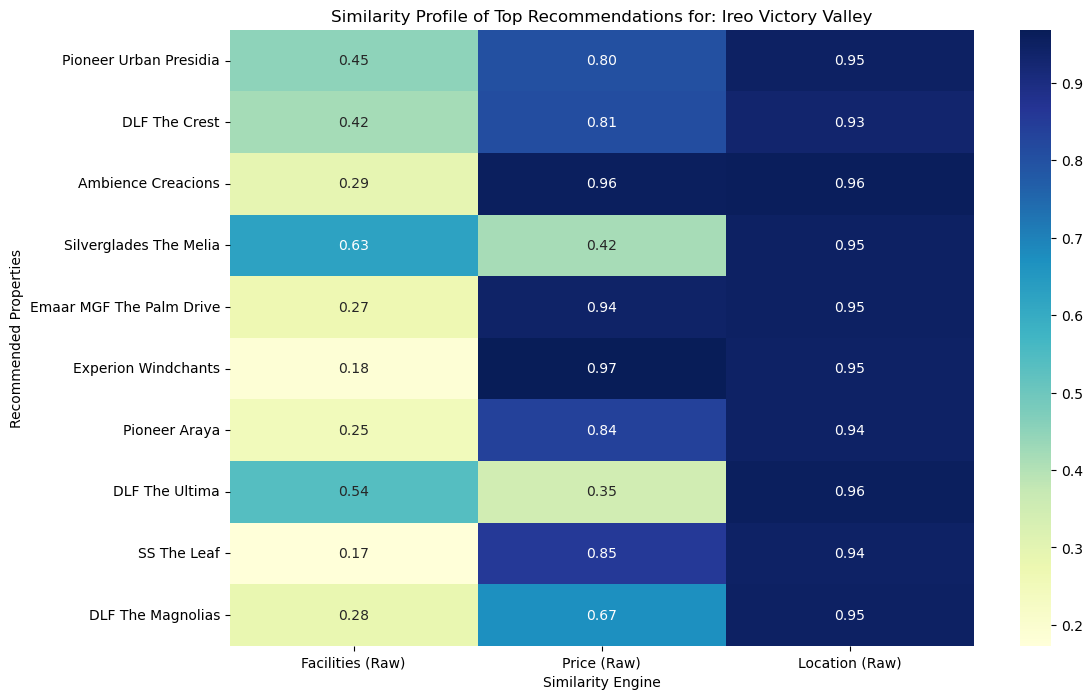

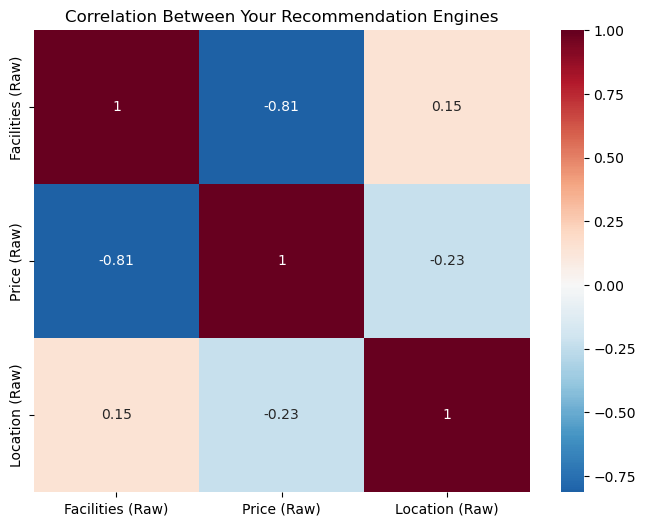

In [63]:
def visualize_engine_contributions(property_name, top_n=10):
    # 1. Get index of the target property
    try:
        idx = location_df_normalized.index.get_loc(property_name)
    except:
        print(f"Property '{property_name}' not found.")
        return

    # 2. Re-calculate the combined scores for this property to find the top N
    # Using your specific weights: 30, 20, 8
    combined_scores = (30 * cosine_sim_top_features[idx] + 
                       20 * cosine_sim_price[idx] + 
                       8 * cosine_sim_location[idx])
    
    # Get indices of top_n properties (excluding itself)
    top_indices = combined_scores.argsort()[-(top_n+1):-1][::-1]
    top_property_names = location_df_normalized.index[top_indices].tolist()

    # 3. Create a comparison dataframe with RAW cosine scores (0 to 1)
    # This shows the "profile" of why they are similar
    data = {
        'Facilities (Raw)': cosine_sim_top_features[idx, top_indices],
        'Price (Raw)': cosine_sim_price[idx, top_indices],
        'Location (Raw)': cosine_sim_location[idx, top_indices]
    }
    
    comparison_df = pd.DataFrame(data, index=top_property_names)

    # 4. Plot 1: The Component Heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(comparison_df, annot=True, cmap='YlGnBu', fmt='.2f')
    plt.title(f'Similarity Profile of Top Recommendations for: {property_name}')
    plt.xlabel('Similarity Engine')
    plt.ylabel('Recommended Properties')
    plt.show()
    
    # 5. Plot 2: Engine Correlation Matrix
    # This shows if the engines are redundant or providing unique value
    plt.figure(figsize=(8, 6))
    correlation_matrix = comparison_df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0)
    plt.title('Correlation Between Your Recommendation Engines')
    plt.show()

# Execute for your test property
visualize_engine_contributions('Ireo Victory Valley')

In [64]:
pickle.dump(location_df, open(r'C:\Users\Jay Patel\Campusx\ml_projects\PropNavigator\data\recommender\location_distance.pkl','wb'))

In [65]:
cosine_sim_location

array([[1.        , 0.97169524, 0.9621831 , ..., 0.95512508, 0.96375804,
        0.96375804],
       [0.97169524, 1.        , 0.97405595, ..., 0.97219229, 0.98097951,
        0.98097951],
       [0.9621831 , 0.97405595, 1.        , ..., 0.97401393, 0.98281762,
        0.98281762],
       ...,
       [0.95512508, 0.97219229, 0.97401393, ..., 1.        , 0.9910424 ,
        0.9910424 ],
       [0.96375804, 0.98097951, 0.98281762, ..., 0.9910424 , 1.        ,
        1.        ],
       [0.96375804, 0.98097951, 0.98281762, ..., 0.9910424 , 1.        ,
        1.        ]])

In [66]:
pickle.dump(cosine_sim_top_features, open(r'C:\Users\Jay Patel\Campusx\ml_projects\PropNavigator\data\recommender\cosine_sim_top_features.pkl','wb'))
pickle.dump(cosine_sim_price, open(r'C:\Users\Jay Patel\Campusx\ml_projects\PropNavigator\data\recommender\cosine_sim_price.pkl','wb'))
pickle.dump(cosine_sim_location, open(r'C:\Users\Jay Patel\Campusx\ml_projects\PropNavigator\data\recommender\cosine_sim_location.pkl','wb'))